## Environment

In [1]:
import getpass

OPENAI_API_KEY = getpass.getpass("Enter your API key:")

Enter your API key: ········


In [2]:
from openai import OpenAI

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=OPENAI_API_KEY,
)

def call_llm(prompt: str) -> str:
    response = client.responses.create(
        model="gpt-5-nano",
        input=prompt
    )
    return response.output_text

## Defining and Using Tools

In [3]:
def build_initial_prompt(tools_descr: str, user_query: str) -> str:
    system_prompt = f"""
    You're a tool-using assistant.

    You have access to the following tools:
    {tools_descr}

    When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
    {{"type": "tool_call", "name": "<tool_name>", "arguments": {{...}}}}

    When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
    {{"type": "final", "answer": "..."}}
    """
    return f"{system_prompt}\n\nUSER: {user_query}\n"

In [4]:
def process_tool_call(json_model_output, tools_by_name):
    tool_name = json_model_output["name"]
    tool_args = json_model_output["arguments"]
    print(f"Executing tool {tool_name} with args: {tool_args}")

    if tool_name not in tools_by_name:
        raise ValueError("Unknown tool")

    tool_result = tools_by_name[tool_name](**tool_args)

    print(f"Tool result: {tool_result}")
    
    return tool_result

In [5]:
import json

def run_agent_inner(prompt, tools_by_name):
    model_output = call_llm(prompt)
    
    json_model_output = json.loads(model_output)
    print(f"model_output: {model_output}")

    # process tool calls if any
    if json_model_output["type"] == "tool_call":
        tool_result = process_tool_call(json_model_output, tools_by_name)
        # call LLM with the tool result
        prompt_with_tools = (
            f"{prompt}\n"
            f"ASSISTANT: {model_output}\n"
            f"TOOL_RESULT: {tool_result}\n"
        )
        return run_agent_inner(prompt_with_tools, tools_by_name)

    print("\n\n===================== LAST PROMPT ==============================")
    print(prompt)
    print(f"DEBUG: {json_model_output}")
    print(f"\n\n== Final result: {json_model_output["answer"]} ===")
    return json_model_output["answer"]

In [6]:
def multiply(a, b):
    return a * b

RAW_TOOLS_BY_NAME = {
    "multiply": multiply
}

RAW_TOOLS_DESCR = """
Tools  name: multiply
Description: Multiply two integers
Arguments:
    - a: integer
    - b: integer
Returns: integer
"""

def run_agent_with_raw_tools(user_query: str):
    print(f"\n\nUser query: {user_query}\n\n")
    prompt = build_initial_prompt(RAW_TOOLS_DESCR, user_query)
    result = run_agent_inner(prompt, RAW_TOOLS_BY_NAME)

In [7]:
run_agent_with_raw_tools("What is 17 multiplied by 23?")



User query: What is 17 multiplied by 23?


model_output: {"type": "tool_call", "name": "multiply", "arguments": {"a": 17, "b": 23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type": "final", "answer": "391"}


===================== LAST PROMPT ==============================

    You're a tool-using assistant.

    You have access to the following tools:
    
Tools  name: multiply
Description: Multiply two integers
Arguments:
    - a: integer
    - b: integer
Returns: integer


    When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "tool_call", "name": "<tool_name>", "arguments": {...}}

    When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "final", "answer": "..."}
    

USER: What is 17 multiplied by 23?

ASSISTANT: {"type": "tool_call", "name": "multiply", "arguments": {"a": 17, "b": 23}}
TOOL_RESULT: 391

DEBUG: {'type': 'fin

In [8]:
run_agent_with_raw_tools("What is 17 multiplied by 23 and multiplied by 10?")



User query: What is 17 multiplied by 23 and multiplied by 10?


model_output: {"type": "tool_call", "name": "multiply", "arguments": {"a": 17, "b": 23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type": "tool_call", "name": "multiply", "arguments": {"a": 17, "b": 23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type": "tool_call", "name": "multiply", "arguments": {"a": 17, "b": 23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"final","answer":"3910"}


===================== LAST PROMPT ==============================

    You're a tool-using assistant.

    You have access to the following tools:
    
Tools  name: multiply
Description: Multiply two integers
Arguments:
    - a: integer
    - b: integer
Returns: integer


    When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "tool_call", "name": "<t

In [9]:
run_agent_with_raw_tools("What is the capital of Switzerland?")



User query: What is the capital of Switzerland?


model_output: {"type": "final", "answer": "Bern"}


===================== LAST PROMPT ==============================

    You're a tool-using assistant.

    You have access to the following tools:
    
Tools  name: multiply
Description: Multiply two integers
Arguments:
    - a: integer
    - b: integer
Returns: integer


    When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "tool_call", "name": "<tool_name>", "arguments": {...}}

    When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "final", "answer": "..."}
    

USER: What is the capital of Switzerland?

DEBUG: {'type': 'final', 'answer': 'Bern'}


== Final result: Bern ===


## Limitations

* How do we add more tools to our toolbox?
* What happens when something changes in a tool?

## Wrapping Tools

In [10]:
from typing import Callable, Any, List, Tuple

In [11]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Tool:
    name: str
    description: str
    func: Callable[..., Any]
    args: list[tuple[str, str]]
    outputs: str

    def __str__(self) -> str:
        args_str = ", ".join(f"{name}: {type_}" for name, type_ in self.args)

        return (
            f"Tool Name: {self.name}, "
            f"Description: {self.description}, "
            f"Arguments: {args_str}, "
            f"Outputs: {self.outputs}"
        )

    def __call__(self, *args, **kwargs):
        return self.func(*args, **kwargs)

In [14]:
multiplier = Tool(
    name="multiplier",
    description="Multiply two integers",
    func=multiply,
    args=[("a", "int"), ("b", "int")],
    outputs="int",
)

In [15]:
str(multiplier)

'Tool Name: multiplier, Description: Multiply two integers, Arguments: a: int, b: int, Outputs: int'

👍🏻 *Now we have an abstraction for unifying tools and working with them in a consistent format.*

❓ But what if something changes in the tool? How do we make sure we do not break the contract for using it?

In [19]:
import inspect

def wrap_tool(func: Callable[..., Any]) -> Tool:
    sig = inspect.signature(func)
    
    # function arguments
    args = []
    for p in sig.parameters.values():
        if p.annotation is inspect._empty:
            annotation_name = "Any"
        else:
            annotation_name = getattr(p.annotation, "__name__", str(p.annotation))
    
    # return type
    if sig.return_annotation is inspect._empty:
        outputs = "Any"
    else:
        outputs = getattr(sig.return_annotation, "__name__", str(sig.return_annotation))

    description = (func.__doc__ or "No description provided").strip()
    name = func.__name__

    return Tool(name, description, func, args, outputs)

## Example

In [20]:
@wrap_tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

In [21]:
str(multiply)

'Tool Name: multiply, Description: Multiply two integers and return the result., Arguments: , Outputs: int'

In [22]:
TOOLS_BY_NAME = {
    "multiply": multiply
}

TOOLS_DESCR = "\n".join([str(t) for t in TOOLS_BY_NAME.values()])

In [23]:
def run_agent_with_tools(user_query: str):
    print(f"\n\nUser query: {user_query}\n\n")
    prompt = build_initial_prompt(TOOLS_DESCR, user_query)
    result = run_agent_inner(prompt, TOOLS_BY_NAME)

In [24]:
run_agent_with_tools("What is 15 multiplied by 12?")



User query: What is 15 multiplied by 12?


model_output: {"type": "tool_call", "name": "multiply", "arguments": {"a": 15, "b": 12}}
Executing tool multiply with args: {'a': 15, 'b': 12}
Tool result: 180
model_output: {"type": "final", "answer": "180"}


===================== LAST PROMPT ==============================

    You're a tool-using assistant.

    You have access to the following tools:
    Tool Name: multiply, Description: Multiply two integers and return the result., Arguments: , Outputs: int

    When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "tool_call", "name": "<tool_name>", "arguments": {...}}

    When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
    {"type": "final", "answer": "..."}
    

USER: What is 15 multiplied by 12?

ASSISTANT: {"type": "tool_call", "name": "multiply", "arguments": {"a": 15, "b": 12}}
TOOL_RESULT: 180

DEBUG: {'type': 'final', 'answer': 

## Using Libraries (LangChain)

Existing libraries such as LangChain save us from having to manually:

* define tool formats
* parse tool calls
* handle tool execution

By automating this process, they provide:

* ways to register tools
* a tool-calling protocol
* an agent loop
* message formatting

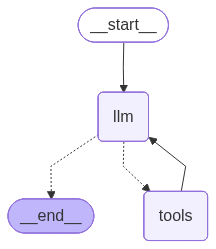

In [28]:
from typing import Annotated, List, TypedDict

from langchain.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

@tool
def multiply(a: int, b: int) -> int:
    "Multiply two integers."""
    return a * b

# Agent state with a reducer: messages will be appended, not overwritten
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENAI_API_KEY,
    model_name="gpt-5-nano",
).bind_tools([multiply])

# LLM node: produce either tool call or a final answer
def llm_node(state: AgentState) -> dict:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

tools_node = ToolNode([multiply])

# Build the graph
graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.add_node("tools", tools_node)

graph.set_entry_point("llm")

# Route to tools if the last AI message contains tool calls, otherwise end
graph.add_conditional_edges("llm", tools_condition, {"tools": "tools", END: END})

# After tools run, go back to the LLM so it can use tool results
graph.add_edge("tools", "llm")

app = graph.compile()
app

In [31]:
messages = [
    SystemMessage(content="You are a tool-using assistant. Always try to use provided tools."),
    HumanMessage(content="What is 17 multiplied by 23?"),
]

result = app.invoke({
    "messages": messages,
})

In [32]:
print(result["messages"][-1].content)

391


In [34]:
# just for understanding what's happening inside
for step in app.stream(
    {
        "messages": messages,
    },
    stream_mode = "values",
):
    last_step = step["messages"][-1]

    print("NODE OUTPUT:")
    print(type(last_step).__name__)

    if hasattr(last_step, "content"):
        print("Content:", last_step.content)

    if hasattr(last_step, "tool_calls") and last_step.tool_calls:
        print("Tool calls:", last_step.tool_calls)

    print("="*50)

NODE OUTPUT:
HumanMessage
Content: What is 17 multiplied by 23?
NODE OUTPUT:
AIMessage
Content: 
Tool calls: [{'name': 'multiply', 'args': {'a': 17, 'b': 23}, 'id': 'call_YQHuWSqNt1ucJkNoTsDycsCD', 'type': 'tool_call'}]
NODE OUTPUT:
ToolMessage
Content: 391
NODE OUTPUT:
AIMessage
Content: 391
